# Principal and Agent

Here, we will work a few simple principal-agent problems using some simple assumptions, with the ultimate aim of figuring out how **[this paper](https://www.aeaweb.org/articles?id=10.1257/aer.20220100)** works. To start, let's pick it up with the cost of effort function, which depends on type. $a$ is effort, $\theta$ is type, and $c(a,\theta)$ are costs of effort. 

Requirements are:

$$
c(0,\theta)=0,c_a>0,c_{aa}>0,c_\theta<0,c_{a\theta}<0,c_{aa\theta}\leq 0 c_{a\theta\theta} \geq 0
$$

So, a potential cost function is:

$$
c(a,\theta) = \frac{a^2}{2\theta}
$$

Let's check, and get the symbolic engine rolling.

In [1]:
from sympy import *

In [2]:
a, theta = symbols('a theta')

In [3]:
c = a**2/(2*theta)

In [4]:
diff(c,a), diff(c, a, a), diff(c, theta), diff(c, a, theta), diff(c, a, a, theta), diff(c, a, theta, theta)

(a/theta, 1/theta, -a**2/(2*theta**2), -a/theta**2, -1/theta**2, 2*a/theta**3)

## Two-state outcomes

Let's get some intuition for the workings of everything by first assuming that there are only two outcomes: good and bad outcomes, which occur with probability $p=\delta a$ and $p'=(1-\delta a)$, where we have to assume that $\delta$ is sufficiently small to keep the values of $p$ and $1-p$ between zero and one. 

We should now be able to figure out, given type, and action, what the lowest cost of implementing any action, under the first-order condition criterion. Suppose the agent gets utility $u_g$ when outcomes are good, and $u_b$ when outcomes are bad. The constraints are, given the agent's type, as follows:

##### Participation
$$
u_g \delta a + (1-\delta a) u_b - \frac{a^2}{2\theta} \geq u_0
$$

##### Incentive Compatibility (FOC)
$$
\delta (u_g-u_b)\theta= a
$$

Suppose utility is $u=w^\rho$, $\rho<1$. Then, we have: $w=u^{\frac{1}{\rho}}$. So, what are the costs of implementing a particular value of $\alpha$? We need to solve the above constraints for $u_g$ and $u_b$, so let's do this as follows:

In [5]:
ug, ub, u0, delta, rho = symbols('u_g u_b u_0 delta rho')

In [6]:
part = ug*delta*a + (1-delta)*ub - a**2/(2*theta) - u0
icom = delta*(ug-ub)*theta - a

In [7]:
solns = solve([part, icom], [ug, ub])

In [8]:
ubsta = solns[ub].simplify()
ugsta = solns[ug].simplify()

To see what these look like, we have $u_b^*$ as follows:

In [10]:
ubsta

(-a**2/2 + theta*u_0)/(theta*(a*delta - delta + 1))

And at the same time, we have $u_g^*$ as follows:

In [11]:
ugsta

(a**2*delta/2 - a*delta + a + delta*theta*u_0)/(delta*theta*(a*delta - delta + 1))

Just out of curiousity, let's look and see what the expected utility of the agent looks like, given these two values:

In [16]:
Eu_1 = ubsta*(1-delta*a) + ugsta*delta*a - a**2/(2*theta)
Eu_1

-a**2/(2*theta) + a*(a**2*delta/2 - a*delta + a + delta*theta*u_0)/(theta*(a*delta - delta + 1)) + (-a**2/2 + theta*u_0)*(-a*delta + 1)/(theta*(a*delta - delta + 1))

In [17]:
Eu = simplify(Eu_1)
Eu

(a**3*delta - a**2*delta + 2*theta*u_0)/(2*theta*(a*delta - delta + 1))

Interesting. We note that this only depends upon reservation utility, $u_0$, and not on the actual values of $u_g$ and $u_b$ chosen by the principal. The costs of implementing a given action, for the principal, are then as follows:

In [18]:
Costnrf = delta*a*ug**(1/rho) + (1-delta*a)*ub**(1/rho)

In [19]:
Cost = Costnrf.subs({ug:ugsta, ub:ubsta}).simplify()

Which I think fits the bill - it depends upon $a$, $\theta$, and $u_0$. It's hard to get a feel for this, so let's see what happens when we substitute in for some of the parameters:

In [20]:
Cost

a*delta*((a**2*delta - 2*a*delta + 2*a + 2*delta*theta*u_0)/(2*delta*theta*(a*delta - delta + 1)))**(1/rho) + ((-a**2 + 2*theta*u_0)/(2*theta*(a*delta - delta + 1)))**(1/rho)*(-a*delta + 1)

In [29]:
Costex = Cost.subs({rho:1/2}).simplify()
Costex

0.25*a*delta*((a**2*delta - 2*a*delta + 2*a + 2*delta*theta*u_0)/(delta*theta*(a*delta - delta + 1)))**2.0 + 0.25*((-a**2 + 2*theta*u_0)/(theta*(a*delta - delta + 1)))**2.0*(-a*delta + 1)

In [30]:
Cost1 = Costex.subs({delta:.025, theta:1, u0:1})
Cost2 = Costex.subs({delta:.025, theta:2, u0:1})
Cost3 = Costex.subs({delta:.025, theta:3, u0:1})

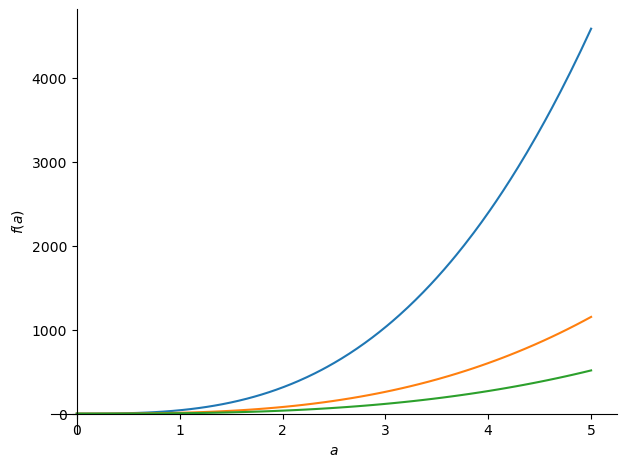

In [31]:
plot(Cost1, Cost2, Cost3, (a, 0, 5))

So, let's go a bit further and think about what happens when we introduce surplus terms for the principal. Let's call these: $s_g$ and $s_b$. Now, we have _total returns_ from given actions to the principal as:

$$
\delta a s_g + (1-\delta a) s_b - C(a,\theta,u_0)
$$

Where the last term is the expected cost to the principal from implementing an action. Plugging in, we have (using our symbolic engine):

In [32]:
sg, sb = symbols('s_g s_b')

In [34]:
Profs = delta*a*sg + (1-delta*a)*sb - Cost
Profs

a*delta*s_g - a*delta*((a**2*delta - 2*a*delta + 2*a + 2*delta*theta*u_0)/(2*delta*theta*(a*delta - delta + 1)))**(1/rho) + s_b*(-a*delta + 1) - ((-a**2 + 2*theta*u_0)/(2*theta*(a*delta - delta + 1)))**(1/rho)*(-a*delta + 1)

So, our principal would choose an optimal action according to the above, which would determine everything else about the problem. Accordingly:

In [38]:
a_foc = diff(Profs, a)
a_foc

-2*a*delta**2*theta*((a**2*delta - 2*a*delta + 2*a + 2*delta*theta*u_0)/(2*delta*theta*(a*delta - delta + 1)))**(1/rho)*(-(a**2*delta - 2*a*delta + 2*a + 2*delta*theta*u_0)/(2*theta*(a*delta - delta + 1)**2) + (2*a*delta - 2*delta + 2)/(2*delta*theta*(a*delta - delta + 1)))*(a*delta - delta + 1)/(rho*(a**2*delta - 2*a*delta + 2*a + 2*delta*theta*u_0)) - delta*s_b + delta*s_g + delta*((-a**2 + 2*theta*u_0)/(2*theta*(a*delta - delta + 1)))**(1/rho) - delta*((a**2*delta - 2*a*delta + 2*a + 2*delta*theta*u_0)/(2*delta*theta*(a*delta - delta + 1)))**(1/rho) - 2*theta*((-a**2 + 2*theta*u_0)/(2*theta*(a*delta - delta + 1)))**(1/rho)*(-a*delta + 1)*(-a/(theta*(a*delta - delta + 1)) - delta*(-a**2 + 2*theta*u_0)/(2*theta*(a*delta - delta + 1)**2))*(a*delta - delta + 1)/(rho*(-a**2 + 2*theta*u_0))

The above is not an easy thing to solve, but can we solve it numerically? 

In [84]:
Profs_example = Profs.subs({rho:.5, delta:.12, theta:2.5, sg:2, sb:1, u0:1}).simplify()
Profs_example

-0.333333333333333*a*((0.12*a**2 + 1.76*a + 0.6)/(0.12*a + 0.88))**2.0 + 0.12*a + ((5.0 - a**2)/(0.12*a + 0.88))**2.0*(0.0048*a - 0.04) + 1

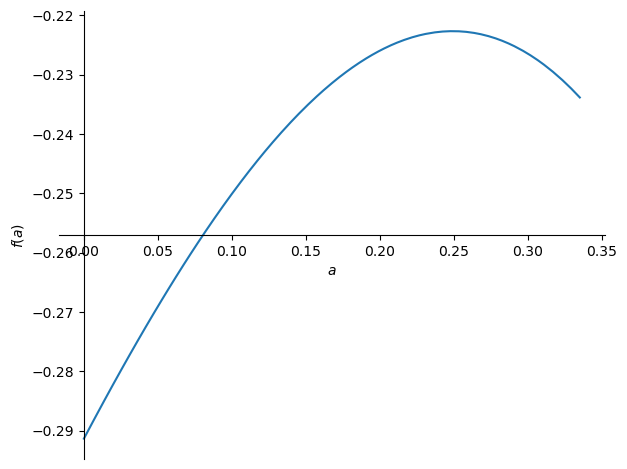

In [86]:
plot(Profs_example, (a, 0, .335))

It's kind of fun to play around with this. But now, what would we do if we faced two different types? Our principal now faces two different problems:

$$
s(a) - C(a,\theta, u_0)
$$

So, we see that it is in fact a well-behaved solution.

So, we see how costs bend as we move from lower to higher values for $\theta$. 

### The relaxed problem

What happens next, now that we have the minimum costs of implementing any action?  We require that any agent that gives us his actual type should follow his first-order condition. We define the surplus for a type $\theta$ agent as:

$$
\delta a u_g + (1-\delta a)u_b - \frac{ca^2}{2\theta}
$$